# RetainIQ — Exploratory Data Analysis
Cookie Cats A/B test: does moving the progression gate from **level 30** to **level 40** change player retention?

This notebook:
1. Loads the raw data
2. Checks that the A/B split is balanced (a randomization sanity check)
3. Computes Day-1 and Day-7 retention rates per group
4. Flags anything that looks like a confound before we trust a causal read of the numbers later (in `frequentist_tests.py` / `bayesian_tests.py`)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


Matplotlib is building the font cache; this may take a moment.


## 1. Load the data

Download `cookie_cats.csv` from Kaggle and place it in `data/`. Columns (per the Kaggle
description):
- `userid` — unique player id
- `version` — `gate_30` or `gate_40` (the experiment arm)
- `sum_gamerounds` — rounds played in the first 14 days
- `retention_1` — bool, did the player come back 1 day after install?
- `retention_7` — bool, did the player come back 7 days after install?


In [2]:
df = pd.read_csv("../data/cookie_cats.csv")
print(df.shape)
df.head()


(90189, 5)


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [3]:
df.info()
df.describe(include="all")


<class 'pandas.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   userid          90189 non-null  int64
 1   version         90189 non-null  str  
 2   sum_gamerounds  90189 non-null  int64
 3   retention_1     90189 non-null  bool 
 4   retention_7     90189 non-null  bool 
dtypes: bool(2), int64(2), str(1)
memory usage: 2.2 MB


,userid,version,sum_gamerounds,retention_1,retention_7
count,"90,189.0000",90189,"90,189.0000",90189,90189
unique,NaN,2,NaN,2,2
top,NaN,gate_40,NaN,False,False
freq,NaN,45489,NaN,50036,73408
mean,"4,998,412.2345",NaN,51.8725,NaN,NaN
std,"2,883,285.6077",NaN,195.0509,NaN,NaN
min,116.0000,NaN,0.0000,NaN,NaN
25%,"2,512,230.0000",NaN,5.0000,NaN,NaN
50%,"4,995,815.0000",NaN,16.0000,NaN,NaN
75%,"7,496,452.0000",NaN,51.0000,NaN,NaN


## 2. Sanity-check the split

Before trusting any causal claim, we need to believe the assignment to `gate_30` vs
`gate_40` was actually random. With this dataset we don't have pre-treatment covariates
(no age, device, country, etc.) — the only two things we CAN check are:

1. **Group sizes are close to a 50/50 split** (or whatever the intended ratio was). A
   large imbalance could indicate a broken randomizer or data collection issue.
2. **No duplicate/bot-like users** that could distort one arm more than the other.

Note: `sum_gamerounds` is a *post-treatment* outcome (it's measured after the gate
placement could have already affected behavior), so it is **not** a valid confound
check — comparing it across groups tells you about the effect, not about whether
assignment was random. We look at it here purely for outlier/data-quality purposes.


In [4]:
# 2a. Group sizes and split ratio
group_counts = df["version"].value_counts()
print(group_counts)

n_total = len(df)
observed_ratio = group_counts / n_total
print("\nObserved split ratio:\n", observed_ratio)

# Chi-square goodness-of-fit test against an assumed intended 50/50 split.
# H0: the true assignment probability is 50/50 for each arm.
expected = [n_total / 2, n_total / 2]
chi2, p_value = stats.chisquare(f_obs=group_counts.values, f_exp=expected)
print(f"\nChi-square test for 50/50 balance: chi2={chi2:.4f}, p={p_value:.4f}")
print("If p is small (<0.05), the split deviates from 50/50 more than chance would predict.")


version
gate_40    45489
gate_30    44700
Name: count, dtype: int64

Observed split ratio:
 version
gate_40   0.5044
gate_30   0.4956
Name: count, dtype: float64

Chi-square test for 50/50 balance: chi2=6.9024, p=0.0086
If p is small (<0.05), the split deviates from 50/50 more than chance would predict.


In [5]:
# 2b. Duplicate / data-quality checks
print("Duplicate userids:", df["userid"].duplicated().sum())
print("Any missing values?\n", df.isnull().sum())

# Look for extreme outliers in sum_gamerounds (e.g. bots grinding thousands of rounds)
print("\nTop 5 sum_gamerounds values:")
print(df["sum_gamerounds"].sort_values(ascending=False).head())


Duplicate userids: 0
Any missing values?
 userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

Top 5 sum_gamerounds values:
57702    49854
7912      2961
29417     2640
43671     2438
48188     2294
Name: sum_gamerounds, dtype: int64


**What to look for:** the Cookie Cats dataset has one well-known data quality issue —
a single outlier user with an extremely high `sum_gamerounds` (in the tens of thousands).
Decide now (and document your decision) whether to drop this user. Dropping obvious bot-like
outliers is reasonable and standard, but do it for a stated reason, not to move a p-value.


In [6]:
# Example: flag (don't silently drop) the extreme outlier for a documented decision later
outlier_threshold = df["sum_gamerounds"].quantile(0.999)
outliers = df[df["sum_gamerounds"] > outlier_threshold]
print(f"Users above the 99.9th percentile ({outlier_threshold:.0f} rounds): {len(outliers)}")
outliers


Users above the 99.9th percentile (1074 rounds): 91


,userid,version,sum_gamerounds,retention_1,retention_7
655,69927,gate_30,1906,True,True
1097,121303,gate_30,1374,True,True
2257,248748,gate_30,1309,True,True
2586,284610,gate_30,1252,True,True
2692,294376,gate_40,1315,True,True
...,...,...,...,...,...
85964,9521620,gate_40,1252,True,True
86047,9530845,gate_40,1145,True,True
86904,9628337,gate_40,1082,True,True
87007,9640085,gate_30,2156,True,True


## 3. Day-1 and Day-7 retention rates per group

In [7]:
retention_summary = (
    df.groupby("version")[["retention_1", "retention_7"]]
    .mean()
    .rename(columns={"retention_1": "day1_retention", "retention_7": "day7_retention"})
)
retention_summary["n_users"] = df.groupby("version").size()
retention_summary


,day1_retention,day7_retention,n_users
version,,,
gate_30,0.4482,0.1902,44700
gate_40,0.4423,0.1820,45489


C:\Users\nauti\AppData\Local\Temp\ipykernel_15512\2831174920.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\nauti\AppData\Local\Temp\ipykernel_15512\2831174920.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


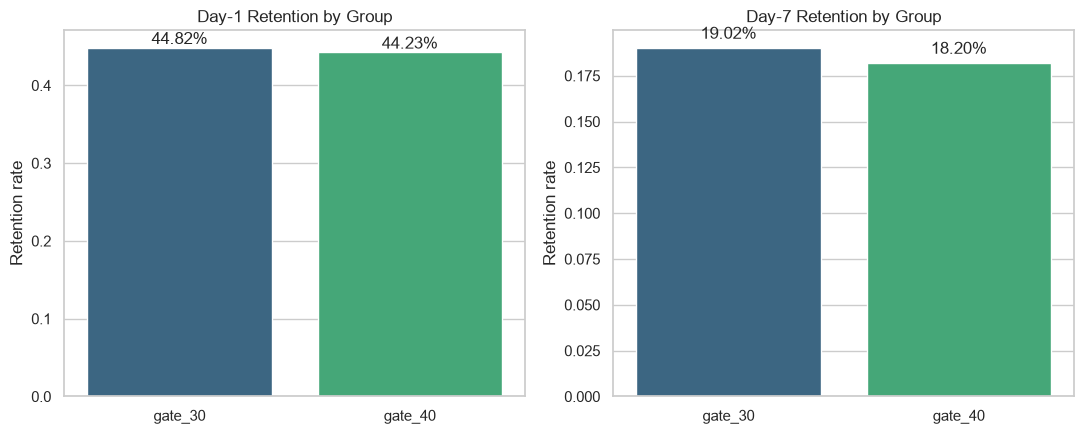

In [8]:
# Visualize
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, col, title in zip(
    axes,
    ["day1_retention", "day7_retention"],
    ["Day-1 Retention by Group", "Day-7 Retention by Group"],
):
    sns.barplot(
        x=retention_summary.index,
        y=retention_summary[col],
        ax=ax,
        palette="viridis",
    )
    ax.set_title(title)
    ax.set_ylabel("Retention rate")
    ax.set_xlabel("")
    for i, v in enumerate(retention_summary[col]):
        ax.text(i, v + 0.005, f"{v:.2%}", ha="center")

plt.tight_layout()
plt.savefig("../reports/retention_by_group.png", dpi=150)
plt.show()


## 4. Quick read (informal — formal testing happens in `src/frequentist_tests.py`)

At a glance:
- Compare `day1_retention` and `day7_retention` between `gate_30` and `gate_40` above.
- A visually small gap doesn't tell you whether it's statistically meaningful — that's
  exactly what the two-proportion z-test (and later, the Bayesian model) is for.
- Note whether the Day-1 and Day-7 gaps point in the *same* direction. If Day-1 favors
  one group but Day-7 favors the other, that's worth flagging and investigating rather
  than picking whichever number tells a cleaner story.

Next notebook cell / next file: feed the counts from `retention_summary` into
`two_proportion_z_test()` and `confidence_interval_diff()` from `src/frequentist_tests.py`.


In [9]:
import sys
sys.path.append("../src")
from frequentist_tests import summarize_ab_test

counts = df.groupby("version")[["retention_1", "retention_7"]].sum()
nobs = df.groupby("version").size()

print("=== Day 1 retention: gate_30 vs gate_40 ===")
summarize_ab_test(
    count_a=counts.loc["gate_30", "retention_1"], nobs_a=nobs["gate_30"],
    count_b=counts.loc["gate_40", "retention_1"], nobs_b=nobs["gate_40"],
)

print("\n=== Day 7 retention: gate_30 vs gate_40 ===")
summarize_ab_test(
    count_a=counts.loc["gate_30", "retention_7"], nobs_a=nobs["gate_30"],
    count_b=counts.loc["gate_40", "retention_7"], nobs_b=nobs["gate_40"],
)


=== Day 1 retention: gate_30 vs gate_40 ===
Group A (e.g. gate_30) rate : 44.8188%  (n=44700)
Group B (e.g. gate_40) rate : 44.2283%  (n=45489)
Difference (B - A)          : -0.5905%
z-statistic                 : 1.7841
p-value                     : 0.0744
Significant at alpha=0.05? : False
Wald  95% CI on diff  : (-1.2392%, +0.0582%)
Wilson 95% CI on diff  : (-1.2392%, +0.0582%)

=== Day 7 retention: gate_30 vs gate_40 ===
Group A (e.g. gate_30) rate : 19.0201%  (n=44700)
Group B (e.g. gate_40) rate : 18.2000%  (n=45489)
Difference (B - A)          : -0.8201%
z-statistic                 : 3.1644
p-value                     : 0.0016
Significant at alpha=0.05? : True
Wald  95% CI on diff  : (-1.3282%, -0.3121%)
Wilson 95% CI on diff  : (-1.3282%, -0.3121%)
